# Prerequisites & Imports

In [1]:
# Prerequisites:
# pip install torch torchvision scikit-learn matplotlib pandas numpy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

# Mount drive
drive.mount('/content/drive')
PROJECT_DIR = "/content/drive/MyDrive/ML2 Final Project"

Mounted at /content/drive


In [2]:
# Create a local directory on the Colab container
!mkdir -p /content/mel_spectrograms

# Copy everything from your Drive shortcut to the local container
!cp -r "/content/drive/MyDrive/ML2 Final Project/mel_spectrograms/." "/content/mel_spectrograms/"

# Config

In [3]:
TRAIN_CSV = "train_split.csv"
VAL_CSV   = "val_split.csv"
TEST_CSV  = "test_split.csv"

MEL_PATH_COL = "mel_path"
LABEL_COL    = "label"

NUM_CLASSES  = 7
BATCH_SIZE   = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS   = 50
PATIENCE     = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading Dataset

In [4]:
class MelSpectrogramSequenceDataset(Dataset):
    """
    Loads mel-spectrogram .npy files and their emotion labels.
    Formats them for recurrent layers: (Time, Features)
    """

    def __init__(self, csv_path, mel_col=MEL_PATH_COL, label_col=LABEL_COL, max_len=130):
        self.df = pd.read_csv(csv_path)
        self.mel_col = mel_col
        self.label_col = label_col
        self.max_len = max_len

        self.df = self.df.dropna(subset=[mel_col, label_col]).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load the mel-spectrogram (128, T)
        mel = np.load(row[self.mel_col])

        # Pad or truncate to fixed time width (T = max_len)
        if mel.shape[1] < self.max_len:
            pad_width = self.max_len - mel.shape[1]
            mel = np.pad(mel, ((0, 0), (0, pad_width)), mode="constant")
        else:
            mel = mel[:, :self.max_len]

        # Normalize to zero mean, unit variance (per-sample)
        mean = mel.mean()
        std = mel.std()
        if std > 0:
            mel = (mel - mean) / std

        # TRANSPOSE for LSTM: (128, 130) -> (130, 128) = (Time, Features)
        mel = mel.T

        mel_tensor = torch.FloatTensor(mel)
        label_tensor = torch.LongTensor([int(row[self.label_col])])

        return mel_tensor, label_tensor.squeeze()

# Model - LSTM Architecture

In [5]:
class EmotionLSTM(nn.Module):
    """
    Bidirectional LSTM for mel-spectrogram classification.

    Input shape:  (batch, 130, 128)  — 130 time frames, 128 mel bands
    Output shape: (batch, NUM_CLASSES)
    """

    def __init__(self, input_size=128, hidden_size=128, num_layers=2, num_classes=NUM_CLASSES):
        super(EmotionLSTM, self).__init__()

        # Bidirectional LSTM block
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input format: (batch, seq, feature)
            bidirectional=True,
            dropout=0.5 if num_layers > 1 else 0
        )

        # Classifier head (hidden_size * 2 because of bidirectional output)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x shape: (batch, seq_len=130, input_size=128)
        lstm_out, _ = self.lstm(x)

        # lstm_out shape: (batch, seq_len=130, hidden_size*2 = 256)
        # We apply global average pooling over the time dimension
        x = torch.mean(lstm_out, dim=1)

        # x shape: (batch, 256)
        x = self.classifier(x)
        return x

# Training and Validation Functions

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for mel, labels in loader:
        mel, labels = mel.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(mel)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * mel.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, f1

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for mel, labels in loader:
            mel, labels = mel.to(device), labels.to(device)

            outputs = model(mel)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * mel.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, f1, all_preds, all_labels

# Plotting Functions

In [7]:
def plot_training_curves(train_losses, val_losses, train_f1s, val_f1s, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(train_losses) + 1)

    ax1.plot(epochs, train_losses, "b-", label="Train Loss", linewidth=2)
    ax1.plot(epochs, val_losses, "r-", label="Val Loss", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training vs Validation Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, train_f1s, "b-", label="Train F1", linewidth=2)
    ax2.plot(epochs, val_f1s, "r-", label="Val F1", linewidth=2)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Weighted F1")
    ax2.set_title("Training vs Validation F1")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_confusion_matrix(labels, preds, label_names, save_path=None):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title("Confusion Matrix — LSTM Model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# Run Pipeline and Train Model

Device: cuda
Loading data...
Sample input shape: torch.Size([130, 128])

Epoch | Train Loss |   Val Loss | Train F1 |   Val F1
    1 |     1.5528 |     1.1620 |   0.3825 |   0.5202
    2 |     1.0806 |     0.7106 |   0.5754 |   0.7603
    3 |     0.8654 |     0.6002 |   0.6597 |   0.7613
    4 |     0.7721 |     0.6200 |   0.6935 |   0.7421
    5 |     0.7320 |     0.5471 |   0.7289 |   0.7890
    6 |     0.6645 |     0.5354 |   0.7505 |   0.7980
    7 |     0.6209 |     0.5465 |   0.7577 |   0.7964
    8 |     0.7105 |     0.7523 |   0.7445 |   0.7457
    9 |     0.6963 |     0.4584 |   0.7402 |   0.8387
   10 |     0.5637 |     0.3948 |   0.7883 |   0.8626
   11 |     0.5270 |     0.4252 |   0.8110 |   0.8350
   12 |     0.4992 |     0.4146 |   0.8106 |   0.8515
   13 |     0.4866 |     0.4203 |   0.8225 |   0.8424
   14 |     0.4323 |     0.3749 |   0.8445 |   0.8687
   15 |     0.4508 |     0.4930 |   0.8397 |   0.8120
   16 |     0.4350 |     0.3710 |   0.8445 |   0.8563
   17 |  

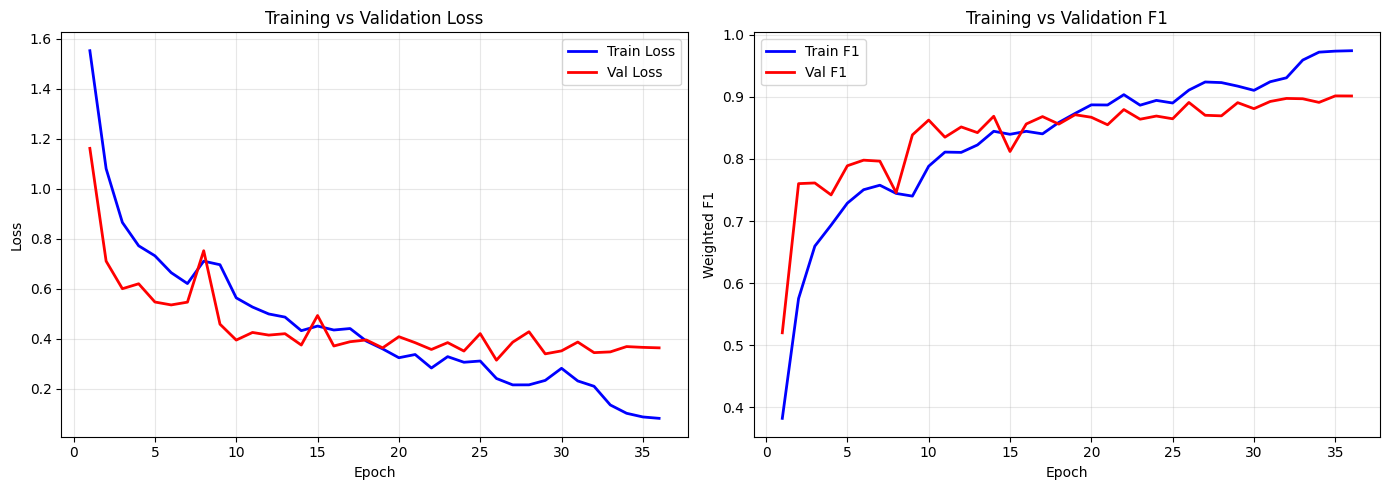

In [8]:
print(f"Device: {DEVICE}")
print(f"Loading data...")

# ── Create datasets and dataloaders ──
train_dataset = MelSpectrogramSequenceDataset(os.path.join(PROJECT_DIR, TRAIN_CSV), max_len=130)
val_dataset   = MelSpectrogramSequenceDataset(os.path.join(PROJECT_DIR, VAL_CSV), max_len=130)
test_dataset  = MelSpectrogramSequenceDataset(os.path.join(PROJECT_DIR, TEST_CSV), max_len=130)

for dataset in [train_dataset, val_dataset, test_dataset]:
    dataset.df["mel_path"] = dataset.df["mel_path"].apply(
        lambda p: os.path.join("/content/mel_spectrograms", p.replace("\\", "/").split("/")[-1])
    )

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verify sample shape
sample_mel, sample_label = train_dataset[0]
print(f"Sample input shape: {sample_mel.shape}")  # Should be (130, 128)

# ── Compute class weights ──
train_labels = train_dataset.df[LABEL_COL].values
class_counts = np.bincount(train_labels.astype(int), minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

# ── Initialize model, loss, optimizer ──
model = EmotionLSTM(input_size=128, hidden_size=128, num_layers=2, num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

# ── Training loop ──
train_losses, val_losses, train_f1s, val_f1s = [], [], [], []
best_val_loss = float('inf')
patience_counter = 0
best_model_path = "best_lstm_model.pt"

print("\n" + "=" * 60)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train F1':>8} | {'Val F1':>8}")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_f1, _, _ = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>10.4f} | {train_f1:>8.4f} | {val_f1:>8.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val loss: {best_val_loss:.4f}")
            break

print(f"\nTraining complete. Best validation loss achieved: {best_val_loss:.4f}")

# Plot results
plot_training_curves(train_losses, val_losses, train_f1s, val_f1s, save_path="lstm_training_curves.png")

# Evaluation and Report


FINAL EVALUATION ON TEST SET (LSTM)

Test Loss: 2.2084
Test Weighted F1: 0.4169

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.49      0.51        47
           1       0.36      0.55      0.44        47
           2       0.50      0.23      0.32        47
           3       0.47      0.38      0.42        47
           4       0.45      0.78      0.57        46
           5       0.28      0.19      0.23        47
           6       0.46      0.40      0.43        47

    accuracy                           0.43       328
   macro avg       0.44      0.43      0.42       328
weighted avg       0.44      0.43      0.42       328



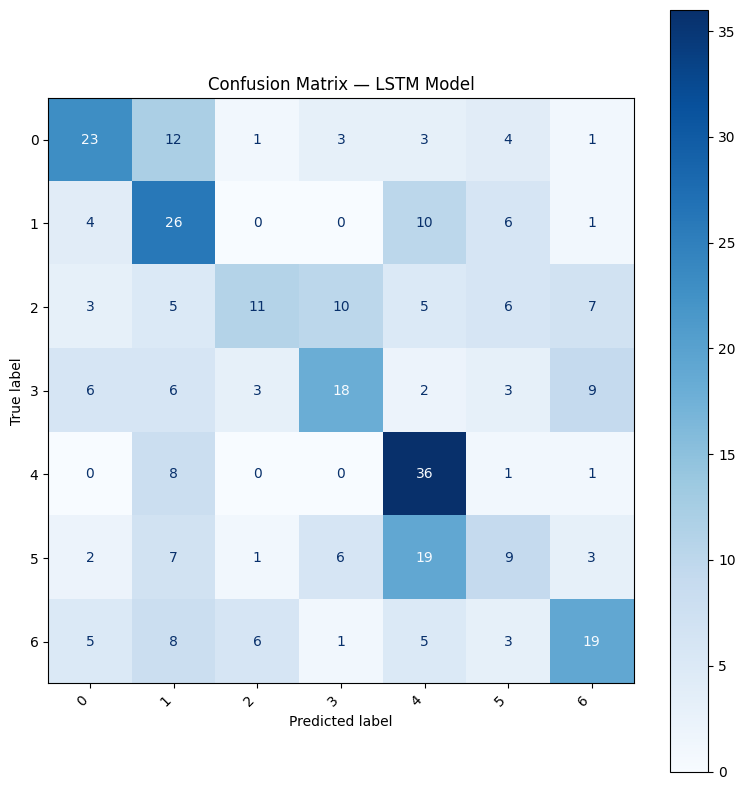


Results saved to lstm_results.json


In [10]:
print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET (LSTM)")
print("=" * 60)

model.load_state_dict(torch.load(best_model_path, weights_only=True))
test_loss, test_f1, test_preds, test_labels = validate(model, test_loader, criterion, DEVICE)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Weighted F1: {test_f1:.4f}")

# Fallback label names if mapping doesn't exist
label_names = [str(i) for i in range(NUM_CLASSES)]
if os.path.exists("label_map.json"):
    import json
    with open("label_map.json", "r") as f:
        label_data = json.load(f)
    int_to_label = label_data.get("int_to_label", {str(v): k for k, v in label_data.items()})
    label_names = [int_to_label.get(str(i), str(i)) for i in range(NUM_CLASSES)]

print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names))

plot_confusion_matrix(test_labels, test_preds, label_names, save_path="lstm_confusion_matrix.png")

# Save results summary
total_params = sum(p.numel() for p in model.parameters())
results = {
    "model": "BiLSTM_Model",
    "input": "mel_spectrogram_sequence",
    "best_val_loss": round(best_val_loss, 4),
    "test_f1": round(test_f1, 4),
    "test_loss": round(test_loss, 4),
    "total_params": total_params,
    "epochs_trained": len(train_losses),
    "best_epoch": len(train_losses) - patience_counter,
}

results_path = "lstm_results.json"
import json
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nResults saved to {results_path}")